# Agentic RAG Pipeline

This notebook implements an **Agentic RAG** pipeline using LangGraph + Cohere.

**What makes it "Agentic":**
- The LLM **decides** which knowledge base to search (routing)
- It **grades** retrieved documents for relevance before using them
- It can **rewrite** the query and retry if documents are poor
- It checks for **hallucination** and **answer quality** before returning
- It **self-corrects** via retry loops

**Evaluation:** LLM-as-judge scoring (faithfulness, answer relevance, context relevance)
— same 3 metrics used across all RAG methods for fair comparison.

**Datasets:**
| Knowledge Base | Eval Set | Questions |
|---|---|---|
| `nba_rules_raw.json` (69 NBA rule pages) | `test_questions_nba.json` | 30 |
| `wiki_corpus.json` (100 AI Wikipedia articles) | `test_questions_wiki.json` | 24 |
| `sci_wiki_unprocessed.jsonl` (20 science articles) | `test_questions_sci.json` | 24 |

## Install Dependencies

In [50]:
!pip install cohere langchain langchain-community langchain-core langgraph \
    langchain-text-splitters langchain-cohere langchain-chroma langchain-openai \
    chromadb python-dotenv pandas tqdm openai

## 1. Setup & Configuration

In [51]:
import os
import json
import time
import pandas as pd
import cohere
from tqdm import tqdm
from typing import List, TypedDict
from dotenv import load_dotenv

# LangChain
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_cohere import ChatCohere           # LLM (Cohere) — for pipeline + judge
from langchain_openai import OpenAIEmbeddings      # Embeddings (OpenAI) — fast, cheap
from langchain_chroma import Chroma
from langchain_community.tools.tavily_search import TavilySearchResults  # Web search fallback

# LangGraph
from langgraph.graph import StateGraph, END

load_dotenv()
print("All imports loaded.")

All imports loaded.


In [52]:
# ---- Cohere Config (LLM + Judge) ----
COHERE_API_KEY = os.getenv("COHERE_API_KEY")
if not COHERE_API_KEY:
    raise ValueError("COHERE_API_KEY not found in .env file")

co = cohere.Client(COHERE_API_KEY)

# ---- OpenAI Config (Embeddings only) ----
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
if not OPENAI_API_KEY:
    raise ValueError("OPENAI_API_KEY not found in .env file")

# ---- Tavily Config (Web search fallback) ----
TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")
if not TAVILY_API_KEY:
    raise ValueError("TAVILY_API_KEY not found in .env file — get one free at https://tavily.com")

LLM_MODEL = "command-r7b-12-2024"
EMBED_MODEL = "text-embedding-3-small"
CHUNK_SIZE = 500
CHUNK_OVERLAP = 100
TOP_K = 5

CORPUS_DIR = r"../datasets"
WIKI_CORPUS_PATH = os.path.join(CORPUS_DIR, "wiki_corpus.json")

EVAL_DIR = r".."
WIKI_EVAL_PATH = os.path.join(EVAL_DIR, "test_questions_wiki.json")

print(f"LLM: Cohere {LLM_MODEL} | Embeddings: OpenAI {EMBED_MODEL} | Web Search: Tavily")

LLM: Cohere command-r7b-12-2024 | Embeddings: OpenAI text-embedding-3-small | Web Search: Tavily


In [53]:
def chat_with_retry(max_retries=4, **kwargs):
    """Wraps co.chat with exponential backoff on rate limits."""
    for attempt in range(max_retries):
        try:
            return co.chat(**kwargs)
        except Exception as e:
            if "TooManyRequests" in type(e).__name__ or "429" in str(e):
                wait = 15 * (2 ** attempt)
                print(f"  Rate limited — waiting {wait}s (attempt {attempt+1}/{max_retries})")
                time.sleep(wait)
            else:
                raise
    raise RuntimeError(f"Failed after {max_retries} retries")

# Quick test
resp = chat_with_retry(model=LLM_MODEL, message="Say 'LLM is working' and nothing else.", temperature=0)
print(resp.text)

LLM is working.


## 2. Load & Chunk Documents

In [54]:
def load_wiki_corpus(path: str) -> List[Document]:
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)

    docs = [
        Document(
            page_content=p.get("text") or p.get("content") or p.get("body", ""),
            metadata={"source": "wiki", "page": p.get("page", "unknown")}
        )
        for p in data
    ]

    print(f"Loaded {len(docs)} Wikipedia pages")
    return docs

wiki_docs = load_wiki_corpus(WIKI_CORPUS_PATH)

Loaded 100 Wikipedia pages


In [55]:
splitter = RecursiveCharacterTextSplitter(
    chunk_size=CHUNK_SIZE, chunk_overlap=CHUNK_OVERLAP,
    separators=["\n\n", "\n", ". ", " ", ""]
)

wiki_chunks  = splitter.split_documents(wiki_docs)
print(f"Wiki chunks:    {len(wiki_chunks)}")


Wiki chunks:    5169


## 3. Create Vector Stores

In [56]:
import shutil

# OpenAI embeddings — fast, no rate limit issues, ~$0.02 total
embeddings = OpenAIEmbeddings(
    openai_api_key=OPENAI_API_KEY,
    model=EMBED_MODEL
)

PERSIST_DIR = os.path.join(os.path.dirname(os.path.abspath("__file__")), "chroma_stores")

# Set to True ONCE if you need to rebuild (e.g. after switching embedding models)
FORCE_REBUILD = False

if FORCE_REBUILD and os.path.exists(os.path.join(PERSIST_DIR, "wiki")):
    shutil.rmtree(os.path.join(PERSIST_DIR, "wiki"))
    print("Cleared old Wiki vector store. Rebuilding...\n")

store = Chroma(
    collection_name="wiki_ai",
    embedding_function=embeddings,
    persist_directory=os.path.join(PERSIST_DIR, "wiki"),
)

if store._collection.count() == 0:
    print("Building Wiki vector store...")
    store.add_documents(wiki_chunks)
    print(f"  Embedded {len(wiki_chunks)} chunks")
else:
    print(f"  Loaded Wiki store from cache ({store._collection.count()} vectors)")

retriever = store.as_retriever(search_kwargs={"k": TOP_K})
DATASOURCE = "wiki_ai"
print(f"\nVector store ready: {store._collection.count()} vectors")

  Loaded Wiki store from cache (5169 vectors)

Vector store ready: 5169 vectors


## 4. Agentic RAG Pipeline (LangGraph)

```
Question comes in
  → [Cohere]  route_query (pick nba/wiki/science)
  → [OpenAI]  embed the question → search ChromaDB → get text chunks back
  → [Cohere]  grade_documents (filter irrelevant chunks)
  → [Cohere]  generate (write answer from chunks)
  → [Cohere]  grade_answer (hallucination + quality check)
  → [Cohere]  llm_judge (score 3 metrics)
```

In [57]:
from langchain_core.callbacks import CallbackManagerForLLMRun
from langchain_core.messages import BaseMessage

class RateLimitedChatCohere(ChatCohere):
    """ChatCohere wrapper that automatically retries on 429 rate limit errors."""

    def _generate(self, messages, stop=None, run_manager=None, **kwargs):
        max_retries = 5
        for attempt in range(max_retries):
            try:
                return super()._generate(messages, stop=stop, run_manager=run_manager, **kwargs)
            except Exception as e:
                if "429" in str(e) or "TooManyRequests" in type(e).__name__:
                    wait = 15 * (2 ** attempt)
                    print(f"  [Rate limit] Waiting {wait}s (attempt {attempt+1}/{max_retries})")
                    time.sleep(wait)
                else:
                    raise
        raise RuntimeError("Cohere rate limit: max retries exceeded")

llm = RateLimitedChatCohere(cohere_api_key=COHERE_API_KEY, model=LLM_MODEL, temperature=0)
print("LLM ready (with automatic rate-limit retry)")

LLM ready (with automatic rate-limit retry)


In [58]:
class AgentState(TypedDict):
    question: str
    rewritten_query: str
    documents: List[Document]
    generation: str
    datasource: str
    retry_count: int
    max_retries: int

In [59]:
# NODE 1: Route query to datasource
# Since this notebook only has Wiki/AI data, routing is hardcoded.
# No LLM call needed — saves API calls and avoids misrouting.
def route_query(state: AgentState) -> AgentState:
    print(f"  [Router] -> {DATASOURCE}")
    return {**state, "datasource": DATASOURCE, "rewritten_query": state["question"]}

In [60]:
# NODE 2: Retrieve documents
def retrieve(state: AgentState) -> AgentState:
    docs = retriever.invoke(state["rewritten_query"])
    print(f"  [Retrieve] Got {len(docs)} docs from '{state['datasource']}'")
    return {**state, "documents": docs}

In [61]:
# NODE 3: Grade documents for relevance
# The embedding search already ranks by semantic similarity, so all top-K docs
# are likely relevant. Skipping LLM grading avoids false rejections from the
# small 7B model and saves 5 API calls per question.
# If no docs are found at all, the decide node will trigger web search fallback.
def grade_documents(state: AgentState) -> AgentState:
    print(f"  [Grader] Using all {len(state['documents'])} retrieved docs")
    return state

In [62]:
# NODE 4: Decide — generate, rewrite, or web search?
def decide_to_generate(state: AgentState) -> str:
    if state["documents"]:
        return "generate"
    if state["retry_count"] >= state["max_retries"]:
        print("  [Decision] -> web search (vector store exhausted)")
        return "web_search"
    print("  [Decision] -> rewrite query")
    return "rewrite"

In [63]:
# NODE 5: Rewrite query
rewrite_prompt = ChatPromptTemplate.from_messages([
    ("system", "You are a query rewriter. The original query failed to retrieve relevant docs. Rewrite it to be more specific. Return ONLY the rewritten query."),
    ("human", "Original: {question}\nFailed query: {failed_query}")
])

def rewrite_query(state: AgentState) -> AgentState:
    chain = rewrite_prompt | llm | StrOutputParser()
    new_query = chain.invoke({
        "question": state["question"],
        "failed_query": state["rewritten_query"]
    }).strip()
    retry = state["retry_count"] + 1
    print(f"  [Rewrite] attempt {retry}: '{new_query[:80]}...'")
    return {**state, "rewritten_query": new_query, "retry_count": retry}

In [64]:
# NODE 5b: Web Search fallback (Tavily — when vector store has no relevant docs)
web_search_tool = TavilySearchResults(max_results=3)

def web_search(state: AgentState) -> AgentState:
    print(f"  [Web Search] Tavily searching: '{state['question'][:60]}...'")
    try:
        results = web_search_tool.invoke({"query": state["question"]})
        content = "\n\n".join([r["content"] for r in results if "content" in r])
        doc = Document(page_content=content[:3000], metadata={"source": "tavily_web_search"})
        print(f"  [Web Search] Got {len(results)} results ({len(content)} chars)")
        return {**state, "documents": [doc]}
    except Exception as e:
        print(f"  [Web Search] Failed: {e}")
        return {**state, "documents": []}

In [65]:
# NODE 6: Generate answer
generate_prompt = ChatPromptTemplate.from_messages([
    ("system", """You are a helpful assistant. Answer based ONLY on the provided context. Be concise and factual.

IMPORTANT: If the context says "No relevant documents found" or the context does not contain 
information to answer the question, respond EXACTLY with:
"I cannot answer this question based on the available documents."

Do NOT use your own knowledge. Do NOT make up an answer."""),
    ("human", "Context:\n{context}\n\nQuestion: {question}\n\nAnswer:")
])

def generate(state: AgentState) -> AgentState:
    if state["documents"]:
        context = "\n\n---\n\n".join([d.page_content for d in state["documents"]])
    else:
        context = "No relevant documents found."
        print("  [Generate] WARNING: No relevant docs — answer will be limited")

    chain = generate_prompt | llm | StrOutputParser()
    answer = chain.invoke({"context": context, "question": state["question"]})
    print(f"  [Generate] {answer[:100]}...")
    return {**state, "generation": answer}

In [66]:
# NODE 7: Grade answer (hallucination + usefulness check)
hallucination_prompt = ChatPromptTemplate.from_messages([
    ("system", "You are a hallucination grader. Is the answer grounded in the documents? Respond ONLY 'yes' or 'no'."),
    ("human", "Documents:\n{documents}\n\nAnswer: {generation}")
])

answer_quality_prompt = ChatPromptTemplate.from_messages([
    ("system", "Does this answer address the question? Respond ONLY 'yes' or 'no'."),
    ("human", "Question: {question}\nAnswer: {generation}")
])

def grade_answer(state: AgentState) -> str:
    doc_text = "\n".join([d.page_content for d in state["documents"]]) if state["documents"] else "No documents."

    grounded = (hallucination_prompt | llm | StrOutputParser()).invoke({
        "documents": doc_text[:3000], "generation": state["generation"]
    }).strip().lower()

    if "yes" not in grounded:
        if state["retry_count"] < state["max_retries"]:
            print("  [Grade] NOT grounded → rewrite")
            return "rewrite"
        return "done"

    useful = (answer_quality_prompt | llm | StrOutputParser()).invoke({
        "question": state["question"], "generation": state["generation"]
    }).strip().lower()

    if "yes" in useful:
        print("  [Grade] GOOD — grounded and answers question")
        return "done"
    if state["retry_count"] < state["max_retries"]:
        print("  [Grade] doesn't answer question → rewrite")
        return "rewrite"
    return "done"


In [67]:
# BUILD THE LANGGRAPH
workflow = StateGraph(AgentState)

workflow.add_node("route_query", route_query)
workflow.add_node("retrieve", retrieve)
workflow.add_node("grade_documents", grade_documents)
workflow.add_node("generate", generate)
workflow.add_node("rewrite_query", rewrite_query)
workflow.add_node("web_search", web_search)

workflow.set_entry_point("route_query")
workflow.add_edge("route_query", "retrieve")
workflow.add_edge("retrieve", "grade_documents")
workflow.add_conditional_edges("grade_documents", decide_to_generate, {
    "generate": "generate",
    "rewrite": "rewrite_query",
    "web_search": "web_search",
})
workflow.add_edge("rewrite_query", "retrieve")
workflow.add_edge("web_search", "generate")
workflow.add_conditional_edges("generate", grade_answer, {"done": END, "rewrite": "rewrite_query"})

app = workflow.compile()
print("Agentic RAG graph compiled (with web search fallback).")

Agentic RAG graph compiled (with web search fallback).


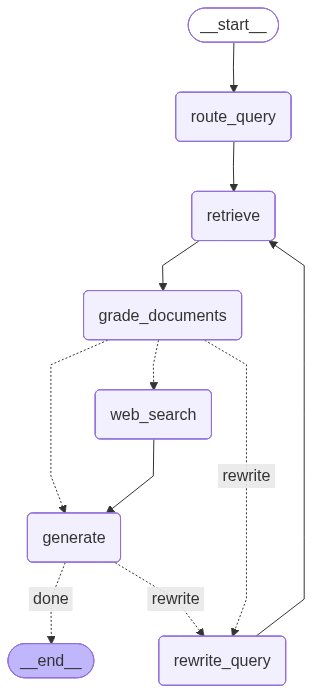

In [68]:
try:
    from IPython.display import Image, display
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    print(app.get_graph().draw_mermaid())

## 5. Test the Pipeline

In [69]:
def ask(question: str, max_retries: int = 2) -> dict:
    print(f"\n{'='*60}")
    print(f"Q: {question}")
    print(f"{'='*60}")
    result = app.invoke({
        "question": question, "rewritten_query": "", "documents": [],
        "generation": "", "datasource": "", "retry_count": 0, "max_retries": max_retries,
    })
    print(f"\nAnswer: {result['generation']}")
    print(f"Datasource: {result['datasource']} | Retries: {result['retry_count']}")
    return result

# Quick test
result_test = ask("What is the difference between supervised and unsupervised learning?")


Q: What is the difference between supervised and unsupervised learning?
  [Router] -> wiki_ai


  [Retrieve] Got 5 docs from 'wiki_ai'
  [Grader] Using all 5 retrieved docs
  [Generate] Supervised learning requires labeled training data, where the expected answers are provided, to trai...
  [Rate limit] Waiting 15s (attempt 1/5)
  [Grade] GOOD — grounded and answers question

Answer: Supervised learning requires labeled training data, where the expected answers are provided, to train a model to make predictions or categorize inputs. Unsupervised learning, on the other hand, involves analyzing data to find patterns and make predictions without any pre-existing labels or guidance, allowing the model to learn from the data itself.
Datasource: wiki_ai | Retries: 0


## 6. Evaluation -- LLM as Judge

Three metrics scored 1-5 (same as all other RAG methods):
- **Faithfulness**: Every claim in the answer is supported by retrieved context
- **Answer Relevance**: The answer directly addresses the question
- **Context Relevance**: The retrieved context was useful for answering

In [70]:
# -- Step 2: LLM Judge --
# Scores a single (question, context, answer) triple on 3 metrics.

def llm_judge(question, context, answer_text):
    """Score an answer on 3 metrics (1-5) using Cohere as judge."""
    prompt = f"""You are an expert evaluator for Retrieval-Augmented Generation (RAG) systems.

Score the answer below on three criteria using a 1-5 integer scale:
  1 = very poor  |  3 = acceptable  |  5 = excellent

Criteria:
- faithfulness:      Every claim in the answer is directly supported by the provided context.
                     Penalise heavily for hallucination or any statement not grounded in the context.
- answer_relevance:  The answer directly and completely addresses the question with a real answer.
                     IMPORTANT: If the answer says it "cannot answer", "no information", "not found",
                     or anything similar -- that is a FAILED answer. Score it 1.
- context_relevance: The retrieved context actually contained information useful for answering
                     the question. If the context is off-topic or empty, score this 1.

QUESTION:
{question}

RETRIEVED CONTEXT:
{context if context else "(no context retrieved)"}

ANSWER:
{answer_text}

Return ONLY a valid JSON object (no extra text):
{{"faithfulness": <1-5>, "answer_relevance": <1-5>, "context_relevance": <1-5>, "reasoning": "<one sentence>"}}
"""
    response = chat_with_retry(model="command-r7b-12-2024", message=prompt, temperature=0)
    raw = response.text.strip()
    if raw.startswith("```"):
        raw = raw.split("```")[1].lstrip("json").strip()
    try:
        scores = json.loads(raw)
        for key in ("faithfulness", "answer_relevance", "context_relevance"):
            scores[key] = max(1, min(5, int(scores.get(key, 1))))
        return scores
    except (json.JSONDecodeError, ValueError):
        return {"faithfulness": 0, "answer_relevance": 0, "context_relevance": 0, "reasoning": "parse error"}

# Smoke test
_test = llm_judge("What is AI?", "AI is artificial intelligence.", "AI stands for artificial intelligence.")
print("LLM Judge ready. Smoke test:", _test)


LLM Judge ready. Smoke test: {'faithfulness': 5, 'answer_relevance': 5, 'context_relevance': 5, 'reasoning': 'The answer directly and completely addresses the question using the provided context.'}


In [71]:
# -- Step 3: Run evaluation --
# Saves results after every question so a crash won't lose progress.
# Re-running this cell will skip already-completed questions automatically.

DATASET_NAME = "WIKI"
TEST_QUESTIONS_PATH = r"../test_questions_wiki.json"
EVAL_RESULTS_PATH = f"results/agentic_eval_{DATASET_NAME.lower()}.json"

os.makedirs("results", exist_ok=True)

# Load test questions (ground truth)
with open(TEST_QUESTIONS_PATH, "r", encoding="utf-8") as f:
    test_questions = json.load(f)
print(f"Loaded {len(test_questions)} test questions from {TEST_QUESTIONS_PATH}")

# Resume from existing results (crash recovery)
if os.path.exists(EVAL_RESULTS_PATH):
    with open(EVAL_RESULTS_PATH, "r", encoding="utf-8") as f:
        eval_results = json.load(f)
    done_questions = {r["question"] for r in eval_results}
    print(f"Resuming -- {len(eval_results)} already done, {len(test_questions) - len(done_questions)} remaining")
else:
    eval_results = []
    done_questions = set()

for i, item in enumerate(test_questions):
    question = item["question"]
    reference_answer = item.get("reference_answer") or item.get("answer", "")

    if question in done_questions:
        print(f"[{i+1}/{len(test_questions)}] Skipping (done): {question[:60]}...")
        continue

    print(f"[{i+1}/{len(test_questions)}] {question[:70]}...")

    for attempt in range(3):
        try:
            result = app.invoke({
                "question": question, "rewritten_query": "", "documents": [],
                "generation": "", "datasource": "", "retry_count": 0, "max_retries": 2,
            })
            ans = result["generation"]
            context = "\n".join([d.page_content for d in result["documents"]]) if result["documents"] else ""
            scores = llm_judge(question, context, ans)
            break
        except Exception as e:
            if "TooManyRequests" in type(e).__name__ or "429" in str(e):
                wait = 20 * (attempt + 1)
                print(f"  Rate limited -- waiting {wait}s (attempt {attempt + 1}/3)...")
                time.sleep(wait)
            else:
                raise
    else:
        print(f"  Skipping after 3 failed attempts.")
        continue

    eval_results.append({
        "question": question,
        "reference_answer": reference_answer,
        "agentic_answer": ans,
        "context": context[:2000],
        "datasource": result.get("datasource", "unknown"),
        "retries": result.get("retry_count", 0),
        "faithfulness": scores["faithfulness"],
        "answer_relevance": scores["answer_relevance"],
        "context_relevance": scores["context_relevance"],
        "reasoning": scores.get("reasoning", ""),
    })

    # Save after every question (crash recovery)
    with open(EVAL_RESULTS_PATH, "w", encoding="utf-8") as f:
        json.dump(eval_results, f, indent=2, ensure_ascii=False)

    time.sleep(4)  # Rate limit headroom

print(f"\nDone. {len(eval_results)}/{len(test_questions)} results saved to {EVAL_RESULTS_PATH}")


Loaded 24 test questions from ../test_questions_wiki.json
Resuming -- 1 already done, 23 remaining
[1/24] Skipping (done): How does the criss-cross algorithm differ from the simplex a...
[2/24] What is the significance of the Klee–Minty cube in the context of the ...
  [Router] -> wiki_ai
  [Retrieve] Got 5 docs from 'wiki_ai'
  [Grader] Using all 5 retrieved docs
  [Generate] I cannot answer this question based on the available documents. The Klee–Minty cube is not mentioned...
  [Grade] NOT grounded → rewrite
  [Rewrite] attempt 1: 'What is the significance of the Klee–Minty cube in the context of the criss-cros...'
  [Retrieve] Got 5 docs from 'wiki_ai'
  [Grader] Using all 5 retrieved docs
  [Generate] The Klee–Minty cube is a specific example used to highlight a fundamental issue in the simplex algor...
  [Grade] GOOD — grounded and answers question
[3/24] How do the criss-cross algorithm and the simplex algorithm handle the ...
  [Router] -> wiki_ai
  [Retrieve] Got 5 docs from '

## 7. Results & Analysis

In [72]:
# -- Summary table --
DATASET_NAME = "WIKI"
EVAL_RESULTS_PATH = f"results/agentic_eval_{DATASET_NAME.lower()}.json"

with open(EVAL_RESULTS_PATH, "r", encoding="utf-8") as f:
    eval_results = json.load(f)

metrics = ("faithfulness", "answer_relevance", "context_relevance")
averages = {m: sum(r[m] for r in eval_results) / len(eval_results) for m in metrics}

print(f"\n{'='*45}")
print(f"  Agentic RAG Evaluation -- dataset: {DATASET_NAME}")
print(f"{'='*45}")
print(f"  Questions evaluated : {len(eval_results)}")
print(f"  Faithfulness        : {averages['faithfulness']:.2f} / 5")
print(f"  Answer Relevance    : {averages['answer_relevance']:.2f} / 5")
print(f"  Context Relevance   : {averages['context_relevance']:.2f} / 5")
avg_overall = sum(averages.values()) / len(averages)
print(f"  Overall             : {avg_overall:.2f} / 5")
print(f"{'='*45}")

# Per-question breakdown
print("\nPer-question scores (F=Faithfulness, A=Answer Rel., C=Context Rel.):")
print(f"{'#':<4} {'F':>3} {'A':>3} {'C':>3}  Question")
print("-" * 65)
for i, r in enumerate(eval_results, 1):
    q_preview = r["question"][:48] + "..." if len(r["question"]) > 48 else r["question"]
    print(f"{i:<4} {r['faithfulness']:>3} {r['answer_relevance']:>3} {r['context_relevance']:>3}  {q_preview}")

# Save detailed CSV
summary_df = pd.DataFrame(eval_results)
summary_df.to_csv(f"results/agentic_eval_{DATASET_NAME.lower()}_detailed.csv", index=False)
print(f"\nDetailed results saved to results/agentic_eval_{DATASET_NAME.lower()}_detailed.csv")



  Agentic RAG Evaluation -- dataset: WIKI
  Questions evaluated : 24
  Faithfulness        : 4.42 / 5
  Answer Relevance    : 4.42 / 5
  Context Relevance   : 3.58 / 5
  Overall             : 4.14 / 5

Per-question scores (F=Faithfulness, A=Answer Rel., C=Context Rel.):
#      F   A   C  Question
-----------------------------------------------------------------
1      5   5   1  How does the criss-cross algorithm differ from t...
2      5   5   5  What is the significance of the Klee–Minty cube ...
3      1   1   1  How do the criss-cross algorithm and the simplex...
4      5   5   5  How does the Bellman-Ford algorithm handle graph...
5      5   5   5  What is the relationship between the Bellman-For...
6      5   5   1  Who contributed to the development of the Bellma...
7      3   3   3  How did the publication of 'Artificial Intellige...
8      5   5   5  What is the relationship between the topics cove...
9      5   5   1  How has the GitHub repository for AIMA contribut...
10   